# Sistema neuronal confiable para concesion de credito

Notebook final limpio del MVP sobre Home Credit Default Risk. Ejecuta el flujo defendible de la practica sin reentrenar modelos por defecto: carga datos, audita el preprocesamiento, valida artefactos canonicos y genera las figuras obligatorias de arquitectura FAIR e incertidumbre.

El objetivo es tener una entrega reproducible y estable: los entrenamientos largos quedan fuera de este notebook para evitar que un rerun estocastico sustituya resultados ya validados.


## 0. Configuracion global

Se definen rutas, semillas, estilo visual y artefactos esperados. Las figuras nuevas se guardan en `results/figures/final_clean/` para no sobrescribir graficos previos.


In [1]:
from pathlib import Path
import os
import random
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS = PROJECT_ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
FIGURES_CLEAN = FIGURES / "final_clean"

FIGURES_CLEAN.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True
warnings.filterwarnings("ignore", category=FutureWarning)

LAMBDA_VALUES = (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0)
BATCH_SIZE = 1024

BEST_ARCHITECTURE = {
    "hidden_units": (256, 64, 128, 128),
    "activation": "elu",
    "dropout": 0.20,
    "learning_rate": 9.7804e-4,
}

REQUIRED_ARTIFACTS = {
    "pareto": TABLES / "pareto_results.csv",
    "test_results": TABLES / "test_results_base_vs_fair.csv",
    "history_base": TABLES / "history_fair_lambda_0_0.csv",
    "history_fair": TABLES / "history_fair_lambda_5_0.csv",
    "uncertainty_test": TABLES / "uncertainty_test.csv",
    "uncertainty_target": TABLES / "uncertainty_summary_by_target.csv",
    "uncertainty_ext": TABLES / "uncertainty_by_ext_null_count.csv",
}

missing_artifacts = {name: path for name, path in REQUIRED_ARTIFACTS.items() if not path.exists()}
if missing_artifacts:
    raise FileNotFoundError("Faltan artefactos canonicos: " + str(missing_artifacts))

def save_figure(name: str) -> Path:
    """Guarda la figura actual en la carpeta limpia de figuras finales."""
    path = FIGURES_CLEAN / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("FIGURES_CLEAN:", FIGURES_CLEAN)
print("Artefactos canonicos encontrados:", len(REQUIRED_ARTIFACTS))


PROJECT_ROOT: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani
DATA_RAW: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\data\raw
FIGURES_CLEAN: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\figures\final_clean
Artefactos canonicos encontrados: 7


## 1. Datos y objetivo

El problema es una clasificacion binaria: estimar si una solicitud presenta dificultades de pago (`TARGET=1`) o pago puntual (`TARGET=0`). La variable sensible usada para auditar justicia estadistica es `CODE_GENDER`, restringida a los grupos `F` y `M` para mantener una comparacion binaria estable.


In [2]:
csv_files = sorted(DATA_RAW.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No hay CSVs en {DATA_RAW}. Coloca application_train.csv en data/raw/.")

inventory = pd.DataFrame({
    "archivo": [path.name for path in csv_files],
    "tamano_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_files],
})
display(inventory)

application_train_path = DATA_RAW / "application_train.csv"
if not application_train_path.exists():
    raise FileNotFoundError(f"No existe {application_train_path}.")

raw = pd.read_csv(application_train_path)
raw_fm = raw[raw["CODE_GENDER"].isin(["F", "M"])].copy()

summary = pd.DataFrame({
    "metrica": ["filas originales", "filas F/M", "tasa TARGET", "tasa genero M"],
    "valor": [
        len(raw),
        len(raw_fm),
        raw_fm["TARGET"].mean(),
        (raw_fm["CODE_GENDER"] == "M").mean(),
    ],
})
display(summary)


,archivo,tamano_mb
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
5,HomeCredit_columns_description.csv,0.04
6,installments_payments.csv,689.62
7,POS_CASH_balance.csv,374.51
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


,metrica,valor
0,filas originales,307511.000000
1,filas F/M,307507.000000
2,tasa TARGET,0.080730
3,tasa genero M,0.341648


## 2. EDA minimo para justificar el modelo

El dataset esta desbalanceado: los defaults son una minoria. Tambien existe una variable sensible explicita (`CODE_GENDER`) y fuentes externas (`EXT_SOURCE_*`) con ausencias informativas. Estas observaciones justifican tres decisiones tecnicas: usar metricas robustas al desbalance, anadir una penalizacion FAIR y auditar incertidumbre frente a calidad de datos.


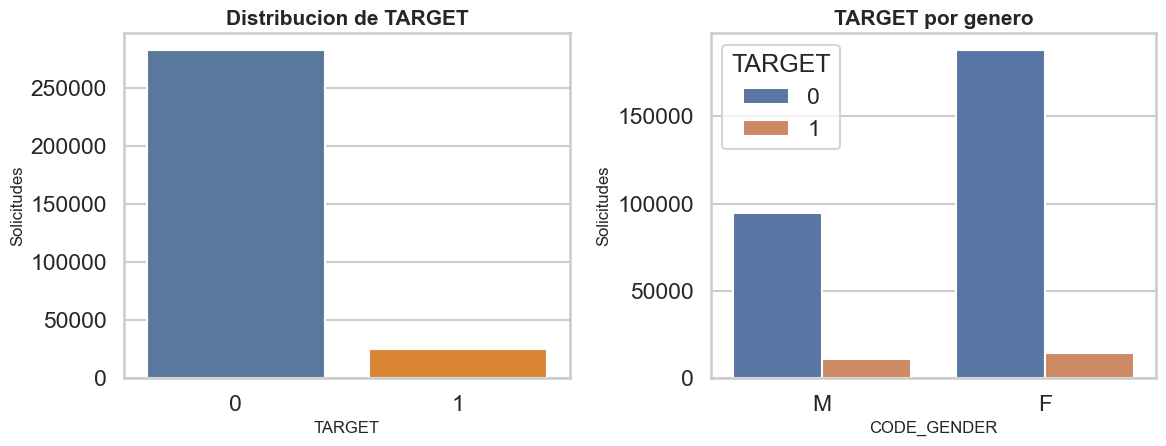

,variable,missing_rate
0,EXT_SOURCE_1,0.563812
1,EXT_SOURCE_3,0.198256
2,EXT_SOURCE_2,0.002146


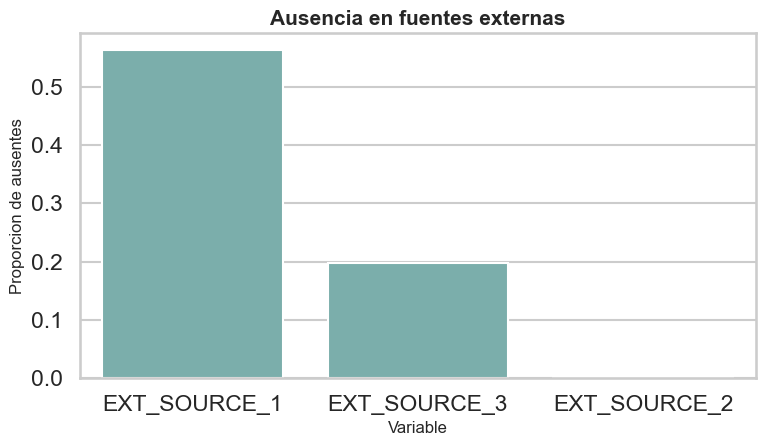

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.countplot(data=raw_fm, x="TARGET", ax=axes[0], palette=["#4C78A8", "#F58518"])
axes[0].set_title("Distribucion de TARGET")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Solicitudes")

sns.countplot(data=raw_fm, x="CODE_GENDER", hue="TARGET", ax=axes[1])
axes[1].set_title("TARGET por genero")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Solicitudes")

save_figure("eda_target_gender.png")
plt.show()

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
missing_ext = raw_fm[ext_cols].isna().mean().sort_values(ascending=False).reset_index()
missing_ext.columns = ["variable", "missing_rate"]
display(missing_ext)

plt.figure(figsize=(8, 4.8))
sns.barplot(data=missing_ext, x="variable", y="missing_rate", color="#72B7B2")
plt.title("Ausencia en fuentes externas")
plt.xlabel("Variable")
plt.ylabel("Proporcion de ausentes")
save_figure("eda_ext_source_missingness.png")
plt.show()


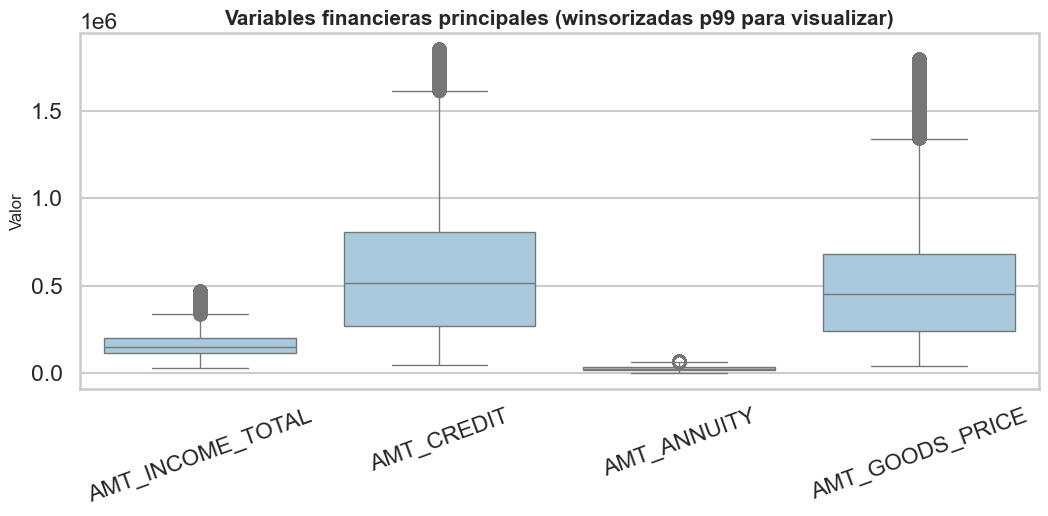

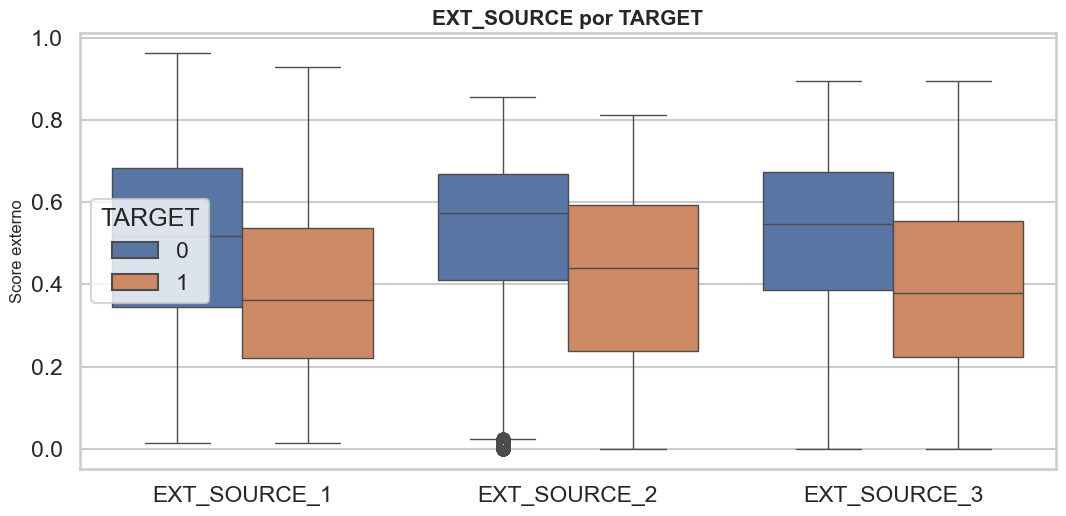

In [4]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
financial_long = raw_fm[financial_cols].clip(upper=raw_fm[financial_cols].quantile(0.99), axis=1).melt(
    var_name="variable",
    value_name="valor_winsorizado_p99",
)

plt.figure(figsize=(11, 5.5))
sns.boxplot(data=financial_long, x="variable", y="valor_winsorizado_p99", color="#A0CBE8")
plt.title("Variables financieras principales (winsorizadas p99 para visualizar)")
plt.xlabel("")
plt.ylabel("Valor")
plt.xticks(rotation=20)
save_figure("eda_financial_boxplots.png")
plt.show()

ext_by_target = raw_fm.melt(
    id_vars="TARGET",
    value_vars=ext_cols,
    var_name="variable",
    value_name="score",
).dropna()

plt.figure(figsize=(11, 5.5))
sns.boxplot(data=ext_by_target, x="variable", y="score", hue="TARGET")
plt.title("EXT_SOURCE por TARGET")
plt.xlabel("")
plt.ylabel("Score externo")
save_figure("eda_ext_source_by_target.png")
plt.show()


## 3. Preprocesamiento sin leakage

El pipeline POO aplica transformaciones deterministas antes del split y ajusta imputacion, escalado y codificacion solo con train. Ademas conserva `EXT_NULL_COUNT` crudo para auditoria semantica de incertidumbre: sus valores deben ser 0, 1, 2 o 3.



X_train: (215254, 36)
X_val: (46126, 36)
X_test: (46127, 36)
Numero de features procesadas: 36


,split,n,target_rate,sensitive_rate,target_0_sensitive_0,target_0_sensitive_1,target_1_sensitive_0,target_1_sensitive_1
0,train,215254,0.080733,0.341648,131794,66082,9919,7459
1,validation,46126,0.080714,0.341651,28242,14161,2125,1598
2,test,46127,0.080734,0.341644,28242,14161,2126,1598


,count
EXT_NULL_COUNT,
0,16448
1,24140
2,5511
3,28


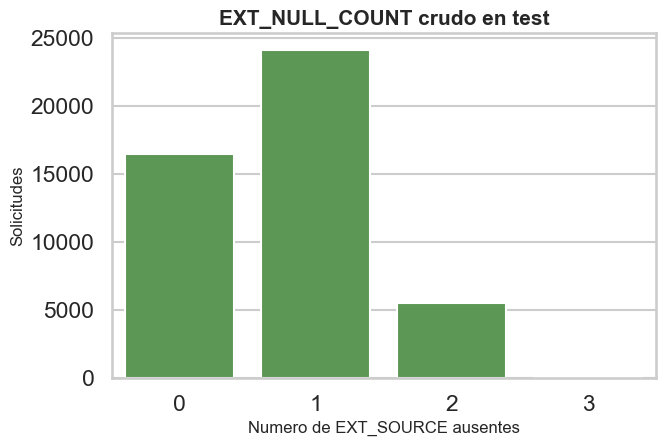

In [5]:
from src.dani_credit.preprocessing import HomeCreditMVPPreprocessingPipeline
from src.dani_credit.splitting import HomeCreditTrainValTestSplitter, SplitConfig

preprocessing_pipeline = HomeCreditMVPPreprocessingPipeline()
raw_loaded = preprocessing_pipeline.load_raw(application_train_path)
deterministic = preprocessing_pipeline.apply_deterministic_transforms(raw_loaded)

splitter = HomeCreditTrainValTestSplitter(SplitConfig(random_state=SEED))
split = splitter.split(deterministic)
processed = preprocessing_pipeline.fit_transform_splits(split.raw_splits)

feature_names = tuple(processed.feature_names)

print("X_train:", processed.X_train.shape)
print("X_val:", processed.X_val.shape)
print("X_test:", processed.X_test.shape)
print("Numero de features procesadas:", len(feature_names))
display(split.report)

ext_values = pd.Series(processed.ext_null_count_test, name="EXT_NULL_COUNT").astype(int)
assert set(ext_values.unique()).issubset({0, 1, 2, 3})
display(ext_values.value_counts().sort_index().rename("count").to_frame())

plt.figure(figsize=(7, 4.8))
sns.countplot(x=ext_values, color="#54A24B")
plt.title("EXT_NULL_COUNT crudo en test")
plt.xlabel("Numero de EXT_SOURCE ausentes")
plt.ylabel("Solicitudes")
save_figure("preprocessing_ext_null_count.png")
plt.show()


## 4. Arquitectura custom y FAIR loss

El modelo usa una red neuronal tabular con capas customizadas para introducir estructura financiera: ratios de importes y transformaciones entrenables para comprimir rangos monetarios. La familia FAIR mantiene la misma arquitectura base y anade una penalizacion de dependencia con genero, controlada por `lambda_fair`.


In [6]:
from src.dani_credit.models import CustomMLPConfig, FairModelConfig

architecture_summary = pd.DataFrame([
    {"componente": "Capas custom financieras", "descripcion": "Ratios financieros y transformacion gamma entrenable"},
    {"componente": "Backbone MLP", "descripcion": f"hidden_units={BEST_ARCHITECTURE['hidden_units']}, activation={BEST_ARCHITECTURE['activation']}, dropout={BEST_ARCHITECTURE['dropout']}"},
    {"componente": "FAIR loss", "descripcion": "BCE + lambda_fair * penalizacion de dependencia prediccion-genero"},
    {"componente": "Seleccion", "descripcion": "Barrido lambda_fair sobre validation y comparacion test Base vs FAIR"},
])
display(architecture_summary)

base_config = CustomMLPConfig(
    hidden_units=BEST_ARCHITECTURE["hidden_units"],
    activation=BEST_ARCHITECTURE["activation"],
    dropout=BEST_ARCHITECTURE["dropout"],
    learning_rate=BEST_ARCHITECTURE["learning_rate"],
)
fair_config = FairModelConfig(lambda_fair=5.0)
print("Config base:", base_config)
print("Config FAIR:", fair_config)


,componente,descripcion
0,Capas custom financieras,Ratios financieros y transformacion gamma entr...
1,Backbone MLP,"hidden_units=(256, 64, 128, 128), activation=e..."
2,FAIR loss,BCE + lambda_fair * penalizacion de dependenci...
3,Seleccion,Barrido lambda_fair sobre validation y compara...


Config base: CustomMLPConfig(hidden_units=(256, 64, 128, 128), activation='elu', dropout=0.2, learning_rate=0.00097804, gradient_clipnorm=1.0, loss='binary_crossentropy', ratio_eps=1.0, ratio_clip_value=10.0, gamma_min=0.1, gamma_max=1.5, theta_init=0.588, gamma_l2_reg=0.0001, gamma_epsilon=1e-06)
Config FAIR: FairModelConfig(lambda_fair=5.0, fairness_eps=1e-08, model_name_prefix='fair_custom_lambda', fairness_layer_name='fair_penalty')


## 5. Pareto FAIR: rendimiento frente a dependencia con genero

La figura obligatoria muestra el intercambio entre rendimiento (`val_auc`) y dependencia con genero (`val_abs_rho`). El punto ideal esta arriba a la izquierda. El modelo FAIR final usa `lambda_fair=5.0`: reduce mucho la dependencia con una caida moderada de AUC.


,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


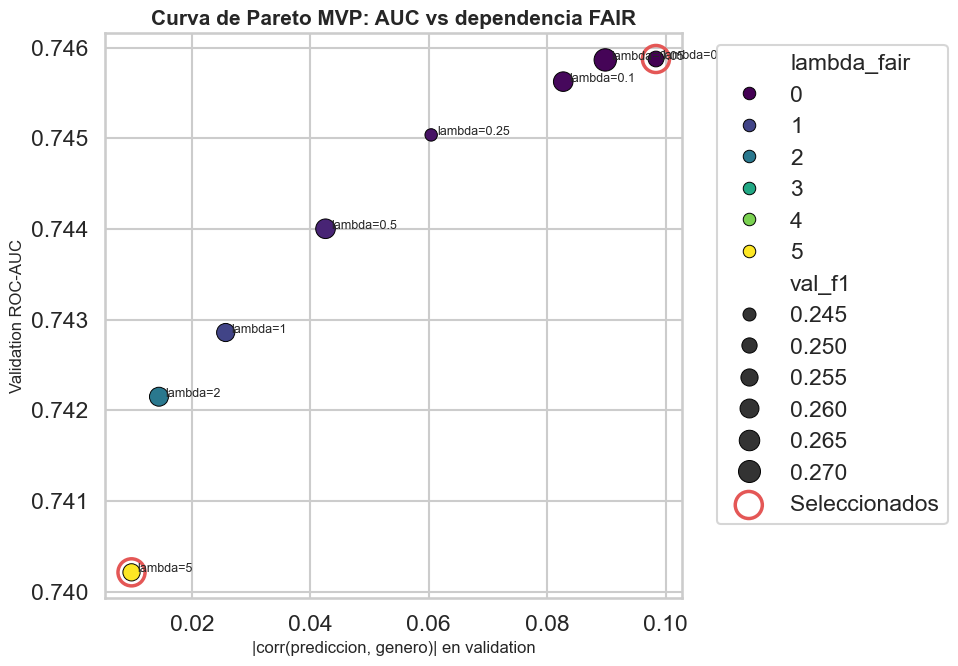

In [7]:
pareto = pd.read_csv(REQUIRED_ARTIFACTS["pareto"])
required_cols = {"lambda_fair", "val_auc", "val_abs_rho", "val_f1", "selected_for_test"}
missing_cols = required_cols.difference(pareto.columns)
if missing_cols:
    raise ValueError(f"Pareto invalida. Faltan columnas: {sorted(missing_cols)}")

expected_lambdas = set(float(value) for value in LAMBDA_VALUES)
observed_lambdas = set(float(value) for value in pareto["lambda_fair"])
assert expected_lambdas.issubset(observed_lambdas)

display(pareto)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pareto,
    x="val_abs_rho",
    y="val_auc",
    hue="lambda_fair",
    size="val_f1",
    sizes=(80, 260),
    palette="viridis",
    edgecolor="black",
    linewidth=0.7,
)
for _, row in pareto.iterrows():
    plt.text(row["val_abs_rho"] + 0.001, row["val_auc"], f"lambda={row['lambda_fair']:g}", fontsize=9)

selected = pareto[pareto["selected_for_test"] == True]
plt.scatter(
    selected["val_abs_rho"],
    selected["val_auc"],
    s=380,
    facecolors="none",
    edgecolors="#E45756",
    linewidths=2.5,
    label="Seleccionados",
)
plt.title("Curva de Pareto MVP: AUC vs dependencia FAIR")
plt.xlabel("|corr(prediccion, genero)| en validation")
plt.ylabel("Validation ROC-AUC")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
save_figure("pareto_auc_vs_fairness.png")
plt.show()


## 6. Curvas de convergencia

Las curvas de perdida permiten verificar que el entrenamiento converge y que la seleccion no se basa en un modelo inestable.


,loss,val_loss,auc,val_auc
48,0.588473,0.599782,0.754080,0.745669
78,0.599117,0.608509,0.747814,0.739958


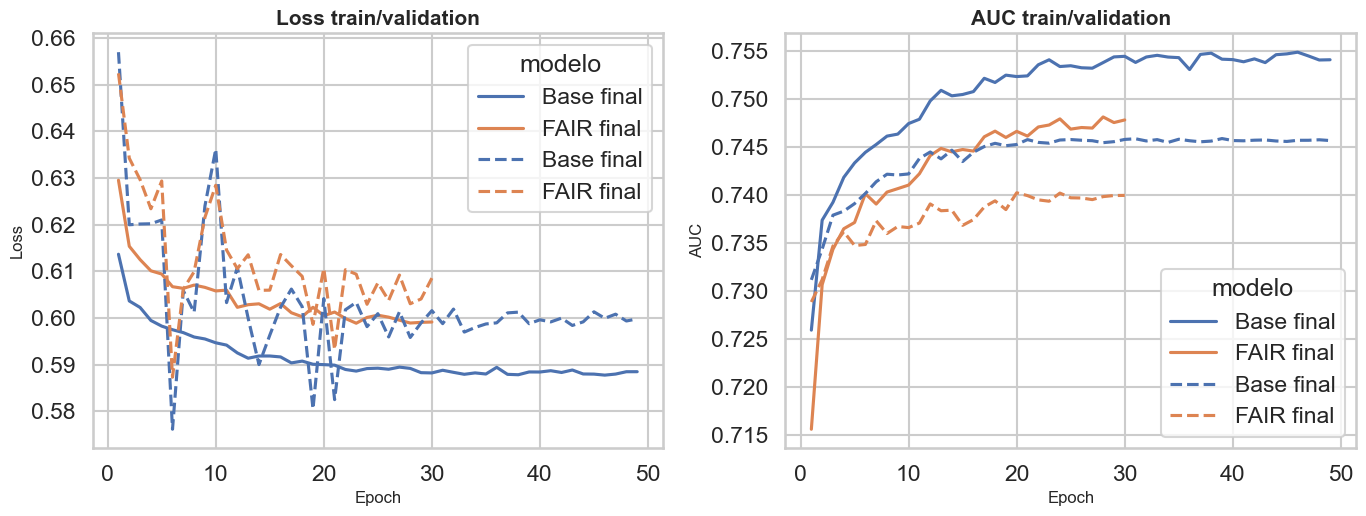

In [8]:
base_row = pareto[np.isclose(pareto["lambda_fair"], 0.0)].iloc[0]
fair_row = pareto[(pareto["selected_for_test"] == True) & (~np.isclose(pareto["lambda_fair"], 0.0))].iloc[0]

history_paths = {
    "Base final": PROJECT_ROOT / base_row["history_path"],
    "FAIR final": PROJECT_ROOT / fair_row["history_path"],
}

histories = []
for model_name, path in history_paths.items():
    if not path.exists():
        raise FileNotFoundError(path)
    history = pd.read_csv(path)
    history["modelo"] = model_name
    history["epoch"] = np.arange(1, len(history) + 1)
    histories.append(history)

history_df = pd.concat(histories, ignore_index=True)
display(history_df.groupby("modelo")[["loss", "val_loss", "auc", "val_auc"]].tail(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.lineplot(data=history_df, x="epoch", y="loss", hue="modelo", ax=axes[0])
sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="modelo", ax=axes[0], linestyle="--")
axes[0].set_title("Loss train/validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=history_df, x="epoch", y="auc", hue="modelo", ax=axes[1])
sns.lineplot(data=history_df, x="epoch", y="val_auc", hue="modelo", ax=axes[1], linestyle="--")
axes[1].set_title("AUC train/validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")

save_figure("training_curves_base_vs_fair.png")
plt.show()


## 7. Evaluacion final en test

Se compara el modelo base (`lambda_fair=0`) con el modelo FAIR seleccionado. Las metricas cubren rendimiento general, clase minoritaria y justicia: ROC-AUC, PR-AUC, recall, F1, correlacion absoluta con genero, demographic parity difference y equalized odds difference.


,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.481516,0.743631,0.222811,0.657186,0.150990,0.702202,0.248539,0.097065,0.088874,0.080517
1,FAIR final,5.0,0.500768,0.738022,0.218571,0.674291,0.154138,0.676155,0.251047,0.008850,0.024762,0.015300


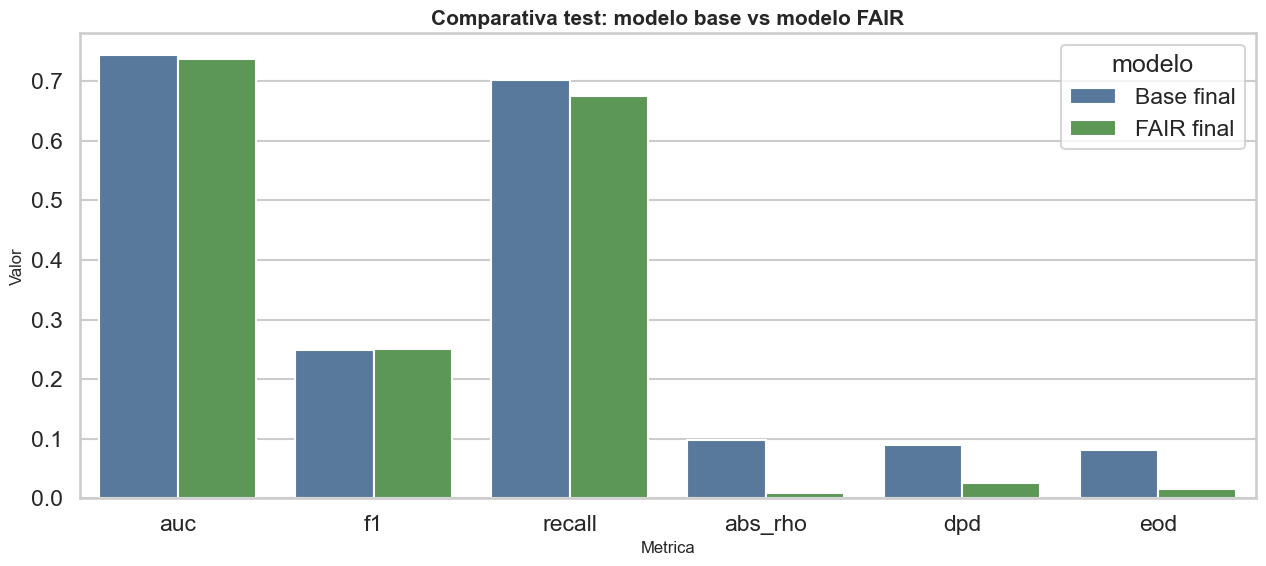

Delta AUC FAIR-base: -0.0056
Reduccion |rho|: 0.0882
Reduccion DPD: 0.0641
Reduccion EOD: 0.0652


In [9]:
test_results = pd.read_csv(REQUIRED_ARTIFACTS["test_results"])
metric_cols = ["auc", "pr_auc", "recall", "f1", "abs_rho", "dpd", "eod"]

display(test_results)

plot_df = test_results.melt(
    id_vars="modelo",
    value_vars=["auc", "f1", "recall", "abs_rho", "dpd", "eod"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="metrica", y="valor", hue="modelo", palette=["#4C78A8", "#54A24B"])
plt.title("Comparativa test: modelo base vs modelo FAIR")
plt.xlabel("Metrica")
plt.ylabel("Valor")
save_figure("test_metrics_base_vs_fair.png")
plt.show()

base = test_results[test_results["modelo"] == "Base final"].iloc[0]
fair = test_results[test_results["modelo"] == "FAIR final"].iloc[0]
print(f"Delta AUC FAIR-base: {fair['auc'] - base['auc']:.4f}")
print(f"Reduccion |rho|: {base['abs_rho'] - fair['abs_rho']:.4f}")
print(f"Reduccion DPD: {base['dpd'] - fair['dpd']:.4f}")
print(f"Reduccion EOD: {base['eod'] - fair['eod']:.4f}")


## 8. Incertidumbre M2

La incertidumbre se estima con un segundo modelo M2 que aprende el error absoluto esperado del clasificador FAIR. El resultado es defendible si la incertidumbre no es constante, separa perfiles faciles/dificiles y aumenta cuando falta informacion externa.


,SK_ID_CURR,y_true,y_pred_label,sensitive,uncertainty,EXT_NULL_COUNT
0,115177,0,0,0,0.420620,0
1,353727,0,0,0,0.219453,0
2,430036,0,1,1,0.679003,1
3,300897,0,1,0,0.758291,1
4,135159,0,0,1,0.308867,0
5,113415,0,1,1,0.532027,1
6,303073,0,0,0,0.236613,1
7,424584,1,1,0,0.714147,1
8,290763,0,0,1,0.168762,0
9,252578,0,1,0,0.495046,1


,y_true,count,uncertainty_mean,uncertainty_median,uncertainty_q1,uncertainty_q3,uncertainty_iqr
0,0,42403,0.406626,0.389211,0.247500,0.548522,0.301023
1,1,3724,0.571869,0.600430,0.445796,0.717490,0.271694


,EXT_NULL_COUNT,count,mean,median
0,0,16448,0.391632,0.362104
1,1,24140,0.424238,0.411613
2,2,5511,0.485151,0.484813
3,3,28,0.552795,0.553184


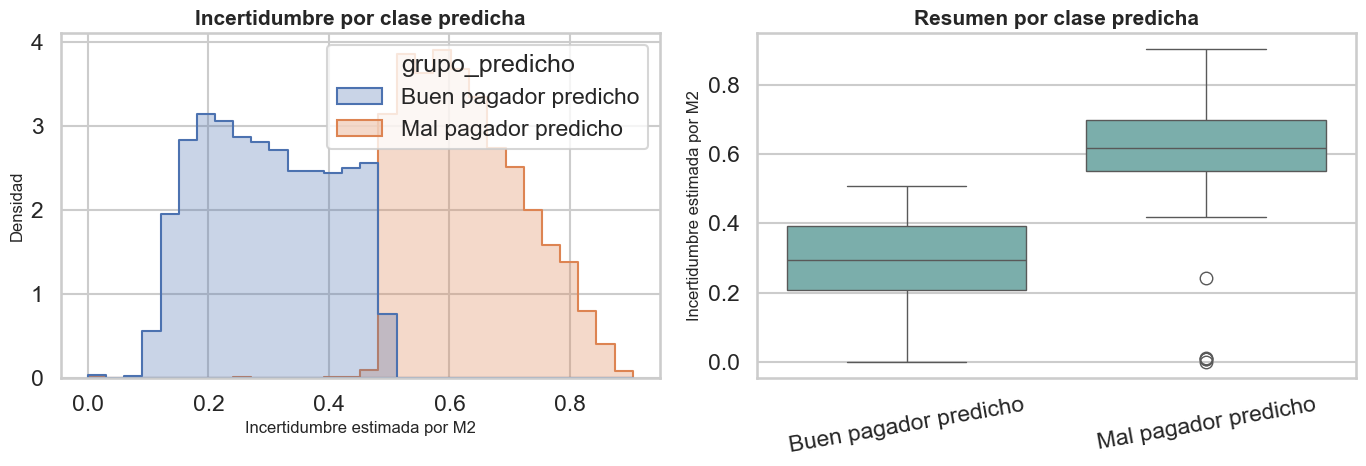

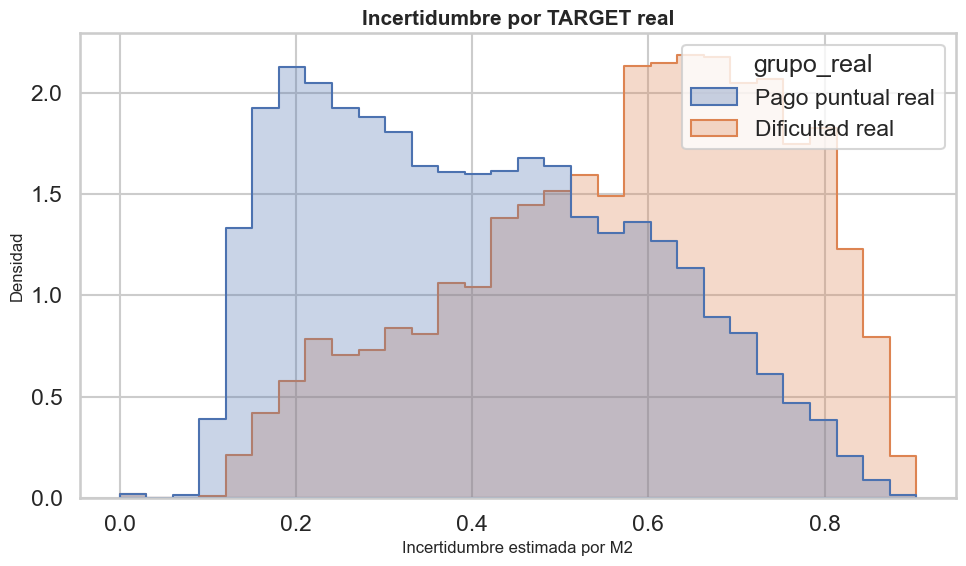

In [10]:
unc = pd.read_csv(REQUIRED_ARTIFACTS["uncertainty_test"])
unc_summary = pd.read_csv(REQUIRED_ARTIFACTS["uncertainty_target"])
unc_ext = pd.read_csv(REQUIRED_ARTIFACTS["uncertainty_ext"])

unc["EXT_NULL_COUNT"] = unc["EXT_NULL_COUNT"].astype(int)
assert unc["uncertainty"].nunique() > 1, "La incertidumbre no puede ser constante."
assert set(unc["EXT_NULL_COUNT"].unique()).issubset({0, 1, 2, 3})

unc_display = unc[["SK_ID_CURR", "y_true", "y_pred_label", "sensitive", "uncertainty", "EXT_NULL_COUNT"]].head(10)
display(unc_display)
display(unc_summary)
display(unc_ext)

unc["grupo_predicho"] = unc["y_pred_label"].map({0: "Buen pagador predicho", 1: "Mal pagador predicho"})
unc["grupo_real"] = unc["y_true"].map({0: "Pago puntual real", 1: "Dificultad real"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_predicho",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
    ax=axes[0],
)
axes[0].set_title("Incertidumbre por clase predicha")
axes[0].set_xlabel("Incertidumbre estimada por M2")
axes[0].set_ylabel("Densidad")

sns.boxplot(data=unc, x="grupo_predicho", y="uncertainty", color="#72B7B2", ax=axes[1])
axes[1].set_title("Resumen por clase predicha")
axes[1].set_xlabel("")
axes[1].set_ylabel("Incertidumbre estimada por M2")
axes[1].tick_params(axis="x", rotation=10)

save_figure("uncertainty_distribution_by_predicted_class.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=unc,
    x="uncertainty",
    hue="grupo_real",
    stat="density",
    common_norm=False,
    bins=30,
    element="step",
    fill=True,
    alpha=0.30,
)
plt.title("Incertidumbre por TARGET real")
plt.xlabel("Incertidumbre estimada por M2")
plt.ylabel("Densidad")
save_figure("uncertainty_distribution_by_target.png")
plt.show()


## 9. Calidad de datos e incertidumbre

`EXT_NULL_COUNT` cuenta cuantas de las tres fuentes externas faltan. Si la incertidumbre crece con este contador, el sistema esta dudando mas cuando la informacion externa es peor, que es el comportamiento esperado para un modelo confiable.


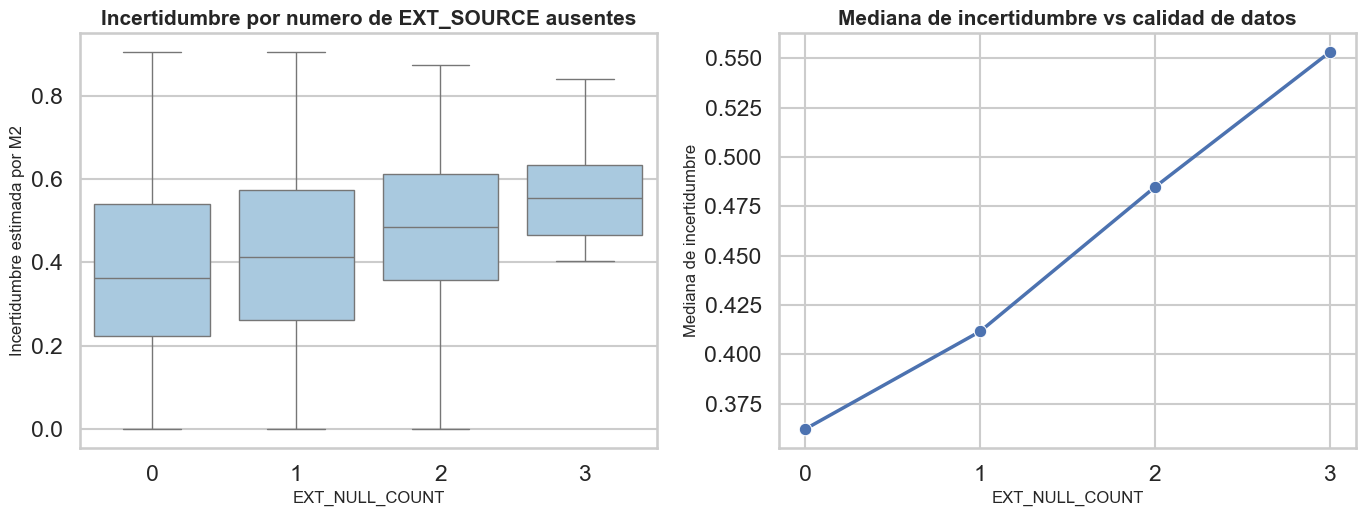

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=unc, x="EXT_NULL_COUNT", y="uncertainty", color="#A0CBE8", ax=axes[0])
axes[0].set_title("Incertidumbre por numero de EXT_SOURCE ausentes")
axes[0].set_xlabel("EXT_NULL_COUNT")
axes[0].set_ylabel("Incertidumbre estimada por M2")

sns.lineplot(data=unc_ext, x="EXT_NULL_COUNT", y="median", marker="o", linewidth=2.5, ax=axes[1])
axes[1].set_title("Mediana de incertidumbre vs calidad de datos")
axes[1].set_xlabel("EXT_NULL_COUNT")
axes[1].set_ylabel("Mediana de incertidumbre")
axes[1].set_xticks([0, 1, 2, 3])

save_figure("ext_null_count_vs_uncertainty.png")
plt.show()


## 10. Conclusiones

El MVP cumple las cuatro tareas obligatorias: arquitectura customizada, FAIR loss, AutoML/Pareto e incertidumbre. El modelo FAIR reduce claramente la dependencia con genero con una perdida moderada de AUC. La incertidumbre M2 no colapsa, diferencia perfiles dificiles y aumenta cuando faltan fuentes externas.


In [12]:
conclusion = pd.DataFrame([
    {"resultado": "AUC base", "valor": base["auc"]},
    {"resultado": "AUC FAIR", "valor": fair["auc"]},
    {"resultado": "|rho| base", "valor": base["abs_rho"]},
    {"resultado": "|rho| FAIR", "valor": fair["abs_rho"]},
    {"resultado": "DPD base", "valor": base["dpd"]},
    {"resultado": "DPD FAIR", "valor": fair["dpd"]},
    {"resultado": "EOD base", "valor": base["eod"]},
    {"resultado": "EOD FAIR", "valor": fair["eod"]},
    {"resultado": "Valores unicos de incertidumbre", "valor": unc["uncertainty"].nunique()},
])
display(conclusion)

print("Resumen defendible:")
print(f"- El modelo FAIR reduce |rho| de {base['abs_rho']:.4f} a {fair['abs_rho']:.4f}.")
print(f"- La perdida de AUC es {base['auc'] - fair['auc']:.4f}.")
print(f"- La incertidumbre mediana TARGET=1 es {unc_summary.loc[unc_summary['y_true'] == 1, 'uncertainty_median'].iloc[0]:.4f}.")
print(f"- La incertidumbre mediana TARGET=0 es {unc_summary.loc[unc_summary['y_true'] == 0, 'uncertainty_median'].iloc[0]:.4f}.")
print("- EXT_NULL_COUNT conserva valores semanticos 0, 1, 2, 3.")


,resultado,valor
0,AUC base,0.743631
1,AUC FAIR,0.738022
2,|rho| base,0.097065
3,|rho| FAIR,0.008850
4,DPD base,0.088874
5,DPD FAIR,0.024762
6,EOD base,0.080517
7,EOD FAIR,0.015300
8,Valores unicos de incertidumbre,46059.000000


Resumen defendible:
- El modelo FAIR reduce |rho| de 0.0971 a 0.0088.
- La perdida de AUC es 0.0056.
- La incertidumbre mediana TARGET=1 es 0.6004.
- La incertidumbre mediana TARGET=0 es 0.3892.
- EXT_NULL_COUNT conserva valores semanticos 0, 1, 2, 3.
